# HYBRID IR: BM25 + LSI (Log-Entropy Weighting) — Grid Search (alpha, k)

**Khác biệt LSI vs LSA trong project này:**
- `lsa.ipynb`: TF-IDF (sublinear) → TruncatedSVD (modern formulation)
- `lsi.ipynb` (file này): **Log-Entropy weighting → TruncatedSVD** (classical Deerwester 1990 formulation)

Mọi thứ còn lại (samples=20k, test queries, alpha-grid, k-grid, metrics, framework đánh giá) đều giống cả 3 notebook để dễ so sánh.

## 1. CÀI ĐẶT THƯ VIỆN

In [1]:
!pip install rank_bm25 datasets pyvi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.3 MB/s eta 0:00:00


In [2]:
import os
import re
import time
import zipfile
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from datasets import load_dataset
from pyvi import ViTokenizer
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

## 2. CẤU HÌNH CHUNG (dùng giống nhau cho LSA / LSI / LDA)

In [3]:
MAX_SAMPLES    = 20000
RANDOM_STATE   = 42
ALPHA_GRID     = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
K_GRID         = [1, 3, 5, 10, 20]
N_COMP_GRID    = [50, 100, 200, 300]
DEFAULT_K      = 10
DEFAULT_N_COMP = 200
MODEL_NAME     = 'lsi'

TEST_QUERIES = [
    {'query': 'thời tiết mưa bão nhiệt độ dự báo',     'category': 'weather',       'keywords': ['thời tiết', 'mưa', 'bão', 'nhiệt độ', 'dự báo']},
    {'query': 'chứng khoán cổ phiếu thị trường đầu tư', 'category': 'stock',         'keywords': ['chứng khoán', 'cổ phiếu', 'thị trường', 'đầu tư']},
    {'query': 'bóng đá việt nam cầu thủ đội tuyển',     'category': 'sports',        'keywords': ['bóng đá', 'việt nam', 'cầu thủ', 'đội tuyển']},
    {'query': 'công nghệ AI trí tuệ nhân tạo máy học',  'category': 'tech',          'keywords': ['công nghệ', 'ai', 'trí tuệ', 'nhân tạo', 'máy học']},
    {'query': 'giá vàng hôm nay tăng mạnh',             'category': 'commodity',     'keywords': ['vàng', 'giá', 'tăng', 'thị trường']},
    {'query': 'dịch covid vaccine tiêm chủng',          'category': 'health',        'keywords': ['covid', 'vaccine', 'dịch', 'bệnh']},
    {'query': 'xe điện vinfast ô tô sản xuất',          'category': 'automotive',    'keywords': ['xe điện', 'vinfast', 'ô tô', 'sản xuất']},
    {'query': 'ca sĩ nhạc mới album âm nhạc',           'category': 'entertainment', 'keywords': ['ca sĩ', 'nhạc', 'album', 'âm nhạc']},
    {'query': 'tội phạm ma túy bắt giữ',                'category': 'crime',         'keywords': ['ma túy', 'tội phạm', 'bắt', 'giữ']},
    {'query': 'tai nạn giao thông xe hỏng',             'category': 'accident',      'keywords': ['tai nạn', 'giao thông', 'xe', 'hỏng']},
    {'query': 'thể thao olympic vàng huy chương',       'category': 'olympic',       'keywords': ['thể thao', 'olympic', 'vàng', 'huy chương']},
    {'query': 'du lịch resort khách sạn nghỉ dưỡng',    'category': 'travel',        'keywords': ['du lịch', 'resort', 'khách sạn', 'nghỉ dưỡng']},
    {'query': 'giáo dục trường học sinh viên',          'category': 'education',     'keywords': ['giáo dục', 'trường', 'học', 'sinh viên']},
    {'query': 'chính trị quốc tế tổng thống',           'category': 'politics',      'keywords': ['chính trị', 'quốc tế', 'tổng thống', 'chính phủ']},
    {'query': 'thời trang làm đẹp con gái',             'category': 'fashion',       'keywords': ['thời trang', 'làm đẹp', 'con gái', 'mỹ phẩm']},
]

np.random.seed(RANDOM_STATE)
print(f'Config: MODEL={MODEL_NAME} | N={MAX_SAMPLES} | |alpha|={len(ALPHA_GRID)} | |k|={len(K_GRID)} | |Q|={len(TEST_QUERIES)}')

Config: MODEL=lsi | N=20000 | |alpha|=11 | |k|=5 | |Q|=15


## 3. TIỀN XỬ LÝ TIẾNG VIỆT

In [4]:
STOPWORDS = set([
    'và', 'của', 'một', 'những', 'các', 'được', 'có', 'là', 'cho', 'khi',
    'đã', 'sẽ', 'nếu', 'như', 'tại', 'vào', 'ra', 'mà', 'này', 'kia', 'đó',
    'ấy', 'thì', 'rằng', 'để', 'với', 'không', 'cũng', 'lại', 'rất', 'nên',
    'bị', 'do', 'về', 'theo', 'qua', 'trong', 'ngoài', 'trên', 'dưới', 'bởi',
    'cả', 'cùng', 'đang', 'đây', 'đến', 'đi', 'hơn', 'kể', 'lên', 'mới',
    'ngay', 'nữa', 'rồi', 'sau', 'thôi', 'thưa'
])
VI_CHARS = (
    'a-z0-9'
    'àáạảãâầấậẩẫăằắặẳẵ'
    'èéẹẻẽêềếệểễ'
    'ìíịỉĩ'
    'òóọỏõôồốộổỗơờớợởỡ'
    'ùúụủũưừứựửữ'
    'ỳýỵỷỹđ'
)
_RE_HTML  = re.compile(r'<[^>]+>')
_RE_URL   = re.compile(r'http\S+|www\S+|https\S+')
_RE_CHARS = re.compile(rf'[^{VI_CHARS}\s_]')
_RE_WS    = re.compile(r'\s+')

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = _RE_HTML.sub(' ', text)
    text = _RE_URL.sub(' ', text)
    text = ViTokenizer.tokenize(text).lower()
    text = _RE_CHARS.sub(' ', text)
    text = _RE_WS.sub(' ', text).strip()
    return ' '.join(t for t in text.split() if t not in STOPWORDS and len(t) > 1)

def minmax_norm(scores) -> np.ndarray:
    arr = np.asarray(scores, dtype=float)
    lo, hi = arr.min(), arr.max()
    return np.zeros_like(arr) if hi == lo else (arr - lo) / (hi - lo)

print('Preprocessing utilities ready.')

Preprocessing utilities ready.


## 4. TẢI VÀ TIỀN XỬ LÝ 20K TÀI LIỆU

In [5]:
print(f'Loading nam194/vietnews [:{MAX_SAMPLES}] ...')
t0 = time.time()
ds = load_dataset('nam194/vietnews', split=f'train[:{MAX_SAMPLES}]')
content_key = 'text' if 'text' in ds[0].keys() else 'article'

titles    = [item.get('title', '') for item in ds]
documents = [item.get(content_key, '') or item.get('abstract', '') for item in ds]
urls      = [item.get('url', 'N/A') for item in ds]
print(f'Loaded {len(documents)} docs in {time.time()-t0:.1f}s | content_key="{content_key}"')

Loading nam194/vietnews [:20000] ...


README.md:   0%|          | 0.00/748 [00:00<?, ?B/s]

data/train-00000-of-00001-84acb79f6c6547(…):   0%|          | 0.00/170M [00:00<?, ?B/s]

data/validation-00000-of-00001-210cc51bf(…):   0%|          | 0.00/38.3M [00:00<?, ?B/s]

data/test-00000-of-00001-123f98d55067eb7(…):   0%|          | 0.00/38.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/99134 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/22184 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22498 [00:00<?, ? examples/s]

Loaded 20000 docs in 37.8s | content_key="article"


In [6]:
t0 = time.time()
processed_docs  = [preprocess_text(d) for d in documents]
tokenized_docs  = [d.split() for d in processed_docs]
documents_lower = [d.lower() for d in documents]
print(f'Preprocessed in {time.time()-t0:.1f}s | avg tokens/doc = {np.mean([len(t) for t in tokenized_docs]):.1f}')

Preprocessed in 242.2s | avg tokens/doc = 271.5


## 5. BM25 (LEXICAL BASELINE)

In [7]:
t0 = time.time()
bm25_model = BM25Okapi(tokenized_docs)
print(f'BM25 built in {time.time()-t0:.1f}s | vocab = {len(bm25_model.idf)}')

BM25 built in 2.2s | vocab = 87931


## 6. LSI = LOG-ENTROPY WEIGHTING → TruncatedSVD

**Classical Deerwester (1990) LSI formulation:**
- Local weight: $L_{ij} = \log(1 + tf_{ij})$
- Global weight: $G_i = 1 - \dfrac{\sum_j p_{ij} \log p_{ij}}{\log N}$ với $p_{ij} = tf_{ij} / \sum_j tf_{ij}$
- Weighted matrix: $A_{ij} = L_{ij} \cdot G_i$ (sau đó SVD)

In [8]:
t0 = time.time()
count_vectorizer = CountVectorizer(
    token_pattern=r'(?u)\b\w+\b',
    max_features=10000,
    min_df=3,
    max_df=0.9,
)
tf_matrix = count_vectorizer.fit_transform(processed_docs)
print(f'Term-doc matrix: {tf_matrix.shape} | nnz={tf_matrix.nnz} | {time.time()-t0:.1f}s')

Term-doc matrix: (20000, 10000) | nnz=2907536 | 6.5s


In [9]:
def log_entropy_weight(tf: sp.spmatrix):
    """Tính log-entropy weighted matrix (CSR).
    Trả về (W, global_weights) — W cùng kiểu sparse với tf.
    """
    tf = tf.tocsr().astype(np.float64)
    n_docs, n_terms = tf.shape

    # Global frequency F_i = sum_j tf_ij
    gf = np.asarray(tf.sum(axis=0)).ravel()  # (n_terms,)
    gf_safe = np.where(gf == 0, 1.0, gf)

    # p_ij = tf_ij / F_i, sau đó sum_j p_ij log p_ij (chỉ tính trên nonzero)
    tf_coo = tf.tocoo()
    p = tf_coo.data / gf_safe[tf_coo.col]
    plogp = p * np.log(p + 1e-12)
    entropy_per_term = np.zeros(n_terms)
    np.add.at(entropy_per_term, tf_coo.col, plogp)

    G = 1.0 + entropy_per_term / np.log(n_docs)
    G = np.clip(G, 0.0, 1.0)

    # Local weight L = log(1 + tf), nhân với G (broadcast theo cột)
    L = tf.copy()
    L.data = np.log1p(L.data)
    diag_G = sp.diags(G)
    W = L @ diag_G
    return W.tocsr(), G

t0 = time.time()
weighted_matrix, global_weights = log_entropy_weight(tf_matrix)
print(f'Log-entropy weighting: {weighted_matrix.shape} | nnz={weighted_matrix.nnz} | {time.time()-t0:.1f}s')
print(f'  G stats: min={global_weights.min():.4f} mean={global_weights.mean():.4f} max={global_weights.max():.4f}')

Log-entropy weighting: (20000, 10000) | nnz=2907536 | 0.3s
  G stats: min=0.0584 mean=0.5691 max=0.9396


In [10]:
lsi_variants = {}
for nc in N_COMP_GRID:
    t0 = time.time()
    svd = TruncatedSVD(n_components=nc, random_state=RANDOM_STATE)
    mat = svd.fit_transform(weighted_matrix)
    lsi_variants[nc] = {
        'model':       svd,
        'matrix':      mat,
        'matrix_norm': normalize(mat),
        'explained':   float(svd.explained_variance_ratio_.sum()),
        'fit_seconds': time.time() - t0,
    }
    print(f'  n_components={nc:>3} | explained={lsi_variants[nc]["explained"]:.4f} | {lsi_variants[nc]["fit_seconds"]:.1f}s')

lsi_model       = lsi_variants[DEFAULT_N_COMP]['model']
lsi_matrix      = lsi_variants[DEFAULT_N_COMP]['matrix']
lsi_matrix_norm = lsi_variants[DEFAULT_N_COMP]['matrix_norm']

  n_components= 50 | explained=0.1388 | 2.5s
  n_components=100 | explained=0.1868 | 4.6s
  n_components=200 | explained=0.2509 | 9.1s
  n_components=300 | explained=0.2994 | 14.5s


In [11]:
def display_lsi_concepts(model, vectorizer, n_concepts=5, n_words=8):
    feat = vectorizer.get_feature_names_out()
    for idx in range(min(n_concepts, model.components_.shape[0])):
        comp = model.components_[idx]
        top = comp.argsort()[-n_words:][::-1]
        print(f'Concept {idx}: ' + ', '.join(f'{feat[i]}({comp[i]:.2f})' for i in top))

display_lsi_concepts(lsi_model, count_vectorizer)

Concept 0: ông(0.10), tôi(0.08), tp(0.08), năm(0.08), người(0.08), anh(0.08), phải(0.07), việc(0.07)
Concept 1: cô(0.16), tôi(0.13), khán_giả(0.12), phim(0.12), diễn_viên(0.11), ca_sĩ(0.11), anh(0.10), mình(0.09)
Concept 2: công_an(0.16), đối_tượng(0.15), sn(0.12), điều_tra(0.12), nạn_nhân(0.10), án(0.10), chị(0.10), vụ(0.10)
Concept 3: bị_cáo(0.22), án(0.11), phiên_toà(0.11), xét_xử(0.10), tội(0.10), hđxx(0.10), luật_sư(0.10), tù(0.09)
Concept 4: bị_cáo(0.22), phí(0.12), xe(0.11), phiên_toà(0.11), giao_thông(0.10), hđxx(0.10), thu(0.10), đồng(0.10)


## 7. HÀM TÌM KIẾM HYBRID — TỐI ƯU

$$\text{score}(d,q) = \alpha \cdot \widetilde{BM25}(d,q) + (1-\alpha) \cdot \widetilde{LSI}(d,q)$$

In [12]:
def project_query_lsi(query: str, svd) -> np.ndarray:
    """Vector hóa query theo log-entropy rồi chiếu sang không gian LSI."""
    pq = preprocess_text(query)
    q_tf = count_vectorizer.transform([pq]).astype(np.float64)
    q_tf.data = np.log1p(q_tf.data)
    q_weighted = q_tf @ sp.diags(global_weights)
    q_lsi = normalize(svd.transform(q_weighted))
    return q_lsi

def compute_query_scores(query: str, mat_norm: np.ndarray, svd):
    pq = preprocess_text(query)
    tokens = pq.split()
    if not tokens:
        n = mat_norm.shape[0]
        return np.zeros(n), np.zeros(n)
    bm25_raw = bm25_model.get_scores(tokens)
    q_lsi    = project_query_lsi(query, svd)
    sem_raw  = cosine_similarity(q_lsi, mat_norm).flatten()
    return minmax_norm(bm25_raw), minmax_norm(sem_raw)

def top_k_indices(scores: np.ndarray, k: int) -> np.ndarray:
    k = min(k, scores.shape[0])
    part = np.argpartition(-scores, k - 1)[:k]
    return part[np.argsort(-scores[part])]

def search_hybrid(query: str, alpha: float = 0.5, top_k: int = DEFAULT_K, svd=None, mat_norm=None):
    svd = svd or lsi_model
    mat_norm = lsi_matrix_norm if mat_norm is None else mat_norm
    bm_n, sem_n = compute_query_scores(query, mat_norm, svd)
    final = alpha * bm_n + (1.0 - alpha) * sem_n
    idx = top_k_indices(final, top_k)
    return idx.tolist(), final[idx].tolist(), {
        'bm25_scores': {int(i): float(bm_n[i]) for i in idx},
        'lsi_scores':  {int(i): float(sem_n[i]) for i in idx},
    }

_idx, _scr, _ = search_hybrid('giá vàng tăng', alpha=0.5, top_k=3)
for i, s in zip(_idx, _scr):
    print(f'{s:.4f}\t{titles[i][:80]}')

1.0000	Giá vàng tăng gần 41 triệu đồng / lượng giữa căng_thẳng Mỹ - Trung
0.8387	Dầu , vàng khó bị ảnh_hưởng nếu Syria không căng
0.7736	Người_dân Vũng_Tàu chen nhau mua vàng , heo quay


## 8. PRE-COMPUTE GROUND-TRUTH RELEVANCE

In [13]:
def build_relevance(test_queries, docs_lower, min_hits: int = 2):
    rel = []
    for tq in test_queries:
        kws = [k.lower() for k in tq['keywords']]
        mask = np.zeros(len(docs_lower), dtype=bool)
        for i, dl in enumerate(docs_lower):
            if sum(1 for k in kws if k in dl) >= min_hits:
                mask[i] = True
        rel.append({'mask': mask, 'total': int(mask.sum())})
    return rel

t0 = time.time()
RELEVANCE = build_relevance(TEST_QUERIES, documents_lower)
print(f'Relevance built in {time.time()-t0:.1f}s | counts = {[r["total"] for r in RELEVANCE]}')

Relevance built in 4.0s | counts = [357, 0, 0, 4, 2602, 386, 0, 149, 3408, 607, 6, 1, 2591, 0, 0]


## 9. GRID SEARCH (alpha × k) — 6 METRICS

In [14]:
def ndcg_at_k(rels, k):
    rels = rels[:k]
    dcg  = sum((2**r - 1) / np.log2(i + 2) for i, r in enumerate(rels))
    idcg = sum((2**r - 1) / np.log2(i + 2) for i, r in enumerate(sorted(rels, reverse=True)))
    return dcg / idcg if idcg > 0 else 0.0

def average_precision(rels):
    hits, ap = 0, 0.0
    for i, r in enumerate(rels):
        if r:
            hits += 1
            ap += hits / (i + 1)
    return ap / hits if hits > 0 else 0.0

def reciprocal_rank(rels):
    for i, r in enumerate(rels):
        if r:
            return 1.0 / (i + 1)
    return 0.0

def query_metrics(ranked_idx, rel_info, k):
    rels = [int(rel_info['mask'][i]) for i in ranked_idx[:k]]
    tp = sum(rels)
    p = tp / k
    r = tp / rel_info['total'] if rel_info['total'] > 0 else 0.0
    return {
        'precision': p, 'recall': r,
        'f1':  2*p*r/(p+r) if (p+r) > 0 else 0.0,
        'map': average_precision(rels),
        'mrr': reciprocal_rank(rels),
        'ndcg': ndcg_at_k(rels, k),
    }

In [15]:
METRIC_KEYS = ['precision', 'recall', 'f1', 'map', 'mrr', 'ndcg']

def grid_search(alpha_grid, k_grid, svd=None, mat_norm=None):
    svd = svd or lsi_model
    mat_norm = lsi_matrix_norm if mat_norm is None else mat_norm
    cached = [compute_query_scores(tq['query'], mat_norm, svd) for tq in TEST_QUERIES]
    out = {a: {k: {m: 0.0 for m in METRIC_KEYS} for k in k_grid} for a in alpha_grid}
    for a in alpha_grid:
        for k in k_grid:
            acc = {m: [] for m in METRIC_KEYS}
            for q_idx, (bm_n, sem_n) in enumerate(cached):
                final = a * bm_n + (1.0 - a) * sem_n
                ranked = top_k_indices(final, k)
                qm = query_metrics(ranked, RELEVANCE[q_idx], k)
                for m in METRIC_KEYS:
                    acc[m].append(qm[m])
            out[a][k] = {m: float(np.mean(v)) for m, v in acc.items()}
    return out

t0 = time.time()
grid_results = grid_search(ALPHA_GRID, K_GRID)
print(f'Grid {len(ALPHA_GRID)}x{len(K_GRID)} done in {time.time()-t0:.1f}s')

Grid 11x5 done in 2.0s


In [16]:
def grid_to_df(grid, metric):
    rows = [{'alpha': a, **{f'k={k}': grid[a][k][metric] for k in K_GRID}} for a in ALPHA_GRID]
    return pd.DataFrame(rows).set_index('alpha').round(4)

for m in METRIC_KEYS:
    print(f'\n=== {m.upper()} ===')
    print(grid_to_df(grid_results, m).to_string())

ndcg_tbl = grid_to_df(grid_results, 'ndcg')
best_alpha, best_k_label = ndcg_tbl.stack().idxmax()
best_k = int(best_k_label.split('=')[1])
print(f'\n>>> Best NDCG: alpha={best_alpha}, k={best_k} (value={ndcg_tbl.stack().max():.4f})')


=== PRECISION ===
          k=1     k=3     k=5    k=10    k=20
alpha                                        
0.0    0.5333  0.4444  0.4400  0.3867  0.3533
0.1    0.5333  0.4667  0.4400  0.4000  0.3600
0.2    0.5333  0.4444  0.4533  0.4067  0.3733
0.3    0.5333  0.4444  0.4400  0.4200  0.3933
0.4    0.6000  0.5111  0.4667  0.4000  0.3833
0.5    0.6000  0.4889  0.4400  0.4000  0.3800
0.6    0.6000  0.4667  0.4400  0.4000  0.3867
0.7    0.5333  0.4667  0.4267  0.4067  0.3800
0.8    0.5333  0.4667  0.4267  0.3933  0.3867
0.9    0.5333  0.4667  0.4400  0.4000  0.3933
1.0    0.5333  0.4667  0.4400  0.4000  0.4000

=== RECALL ===
          k=1     k=3     k=5    k=10    k=20
alpha                                        
0.0    0.0177  0.0357  0.0375  0.0401  0.0452
0.1    0.0177  0.0362  0.0375  0.0410  0.0458
0.2    0.0177  0.0360  0.0489  0.0526  0.0584
0.3    0.0177  0.0471  0.0489  0.0748  0.0824
0.4    0.0288  0.0585  0.0712  0.0750  0.0830
0.5    0.0288  0.0527  0.0544  0.0753  0.0834

## 10. SO SÁNH n_components CỦA LSI

In [17]:
ncomp_results = {}
for nc, info in lsi_variants.items():
    res = grid_search(ALPHA_GRID, [DEFAULT_K], svd=info['model'], mat_norm=info['matrix_norm'])
    a_star = max(ALPHA_GRID, key=lambda a: res[a][DEFAULT_K]['ndcg'])
    ncomp_results[nc] = {
        'best_alpha': a_star,
        'best_ndcg':  res[a_star][DEFAULT_K]['ndcg'],
        'best_map':   res[a_star][DEFAULT_K]['map'],
        'explained':  info['explained'],
        'fit_secs':   info['fit_seconds'],
    }
ncomp_df = pd.DataFrame(ncomp_results).T
ncomp_df.index.name = 'n_components'
print(ncomp_df.round(4).to_string())

              best_alpha  best_ndcg  best_map  explained  fit_secs
n_components                                                      
50                   0.9     0.5512    0.5105     0.1388    2.5327
100                  0.6     0.5722    0.5430     0.1868    4.6091
200                  0.4     0.5766    0.5419     0.2509    9.1061
300                  0.6     0.5693    0.5301     0.2994   14.5142


## 11. TRỰC QUAN HÓA

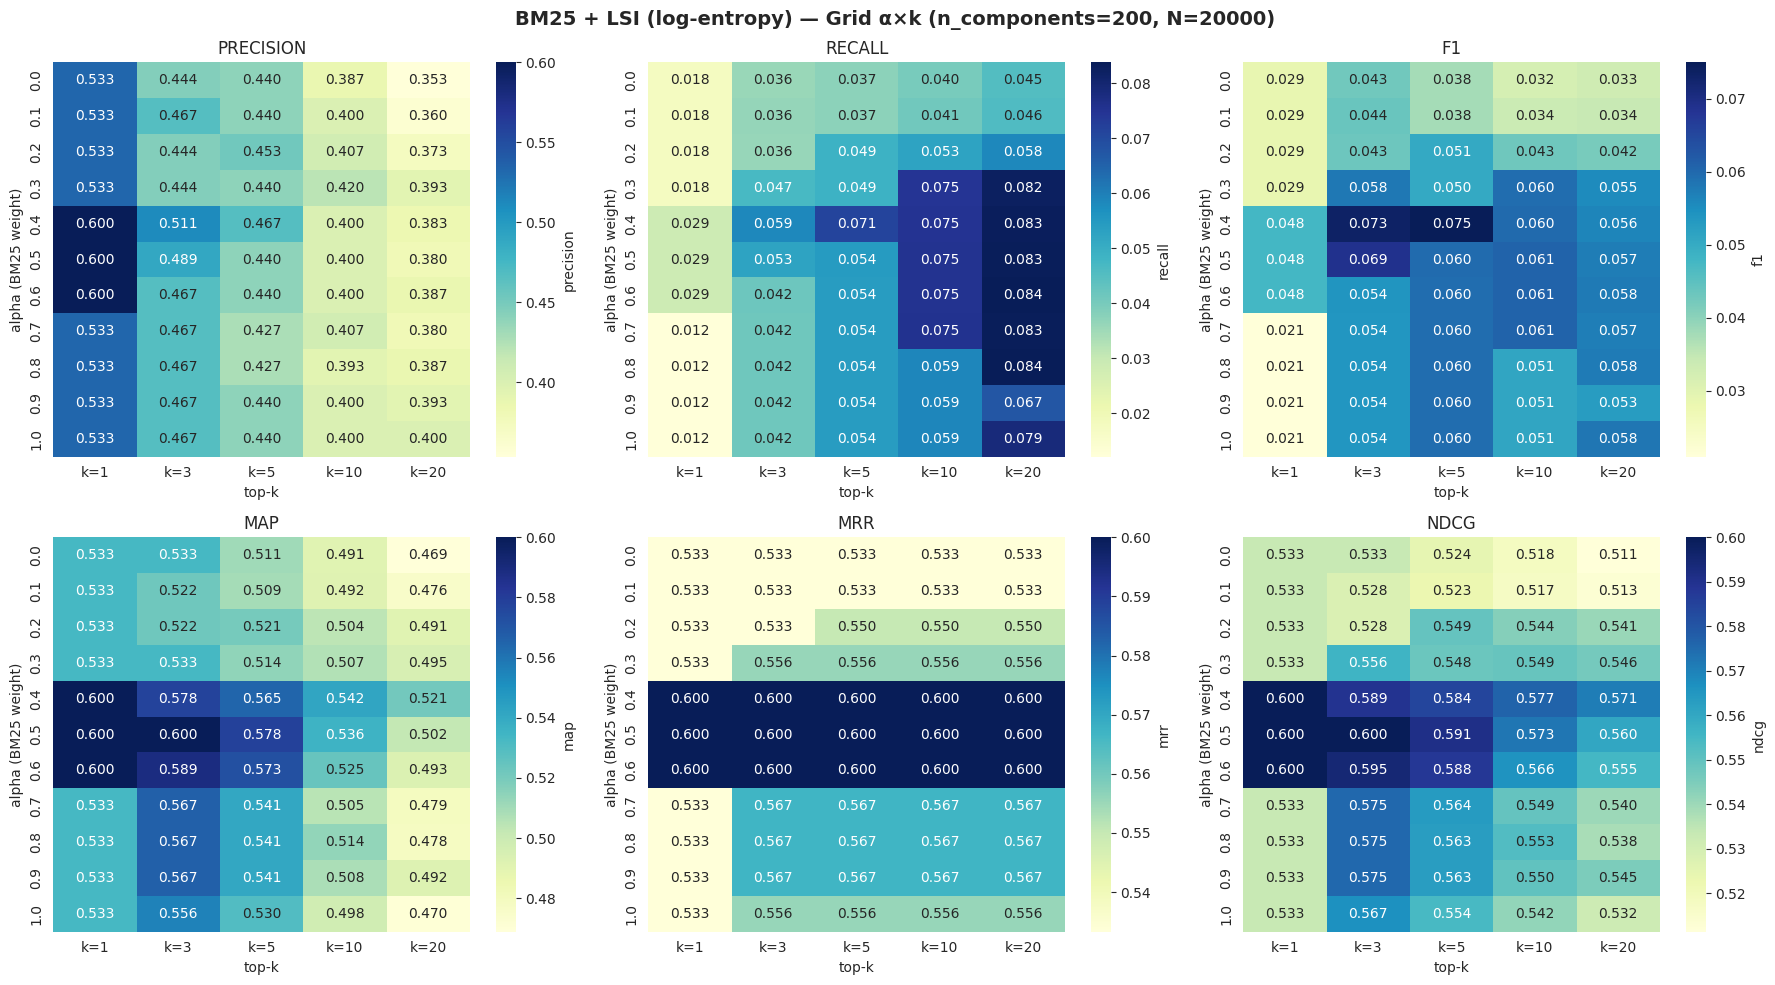

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'BM25 + LSI (log-entropy) — Grid α×k (n_components={DEFAULT_N_COMP}, N={MAX_SAMPLES})',
             fontsize=14, fontweight='bold')
for ax, m in zip(axes.flat, METRIC_KEYS):
    sns.heatmap(grid_to_df(grid_results, m), annot=True, fmt='.3f', cmap='YlGnBu', ax=ax, cbar_kws={'label': m})
    ax.set_title(m.upper())
    ax.set_xlabel('top-k')
    ax.set_ylabel('alpha (BM25 weight)')
plt.tight_layout()
plt.show()

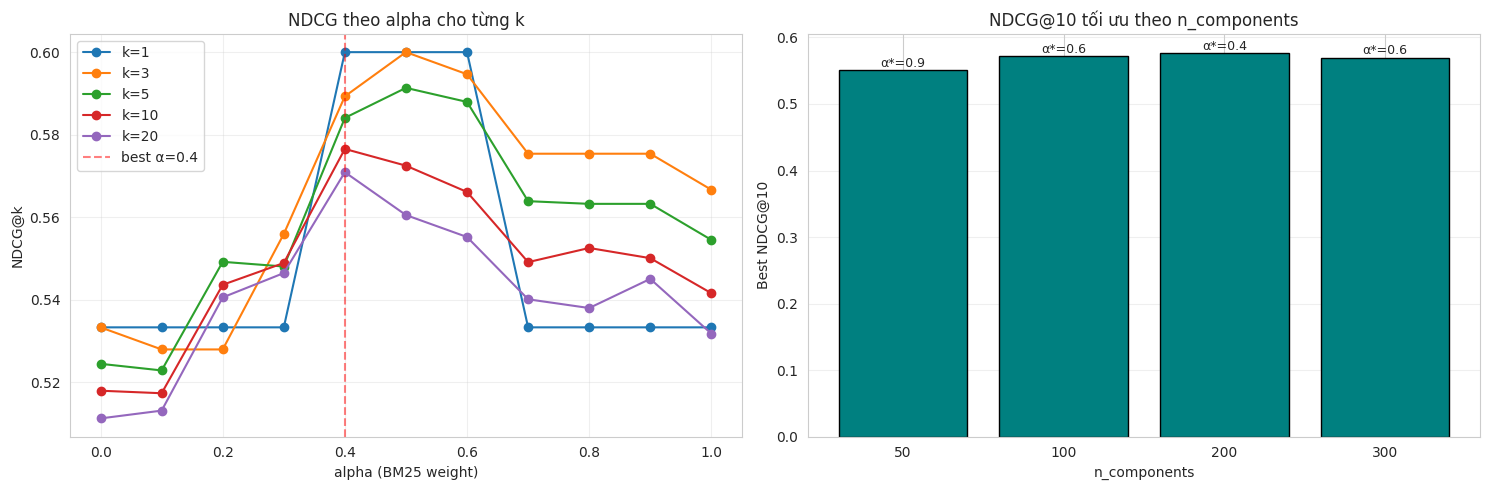

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for k in K_GRID:
    vals = [grid_results[a][k]['ndcg'] for a in ALPHA_GRID]
    ax.plot(ALPHA_GRID, vals, marker='o', label=f'k={k}')
ax.axvline(best_alpha, color='red', linestyle='--', alpha=0.5, label=f'best α={best_alpha}')
ax.set_xlabel('alpha (BM25 weight)'); ax.set_ylabel('NDCG@k')
ax.set_title('NDCG theo alpha cho từng k'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(ncomp_df.index.astype(str), ncomp_df['best_ndcg'], color='teal', edgecolor='black')
for i, (nc, row) in enumerate(ncomp_df.iterrows()):
    ax.text(i, row['best_ndcg'] + 0.005, f"α*={row['best_alpha']}", ha='center', fontsize=9)
ax.set_xlabel('n_components'); ax.set_ylabel('Best NDCG@10')
ax.set_title('NDCG@10 tối ưu theo n_components'); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

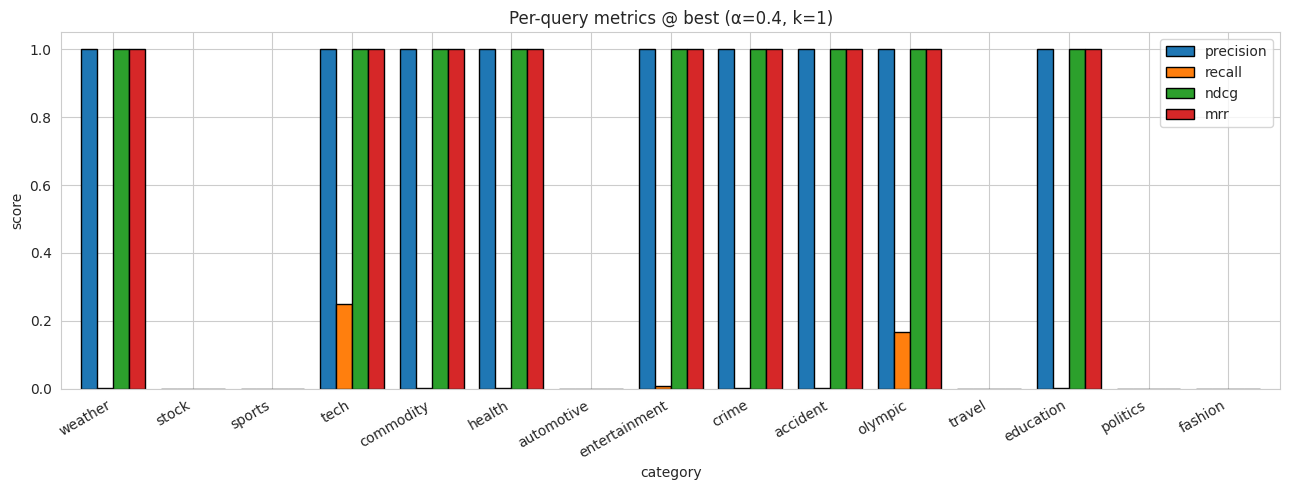

     category                               query  precision  recall     f1  map  mrr  ndcg
      weather   thời tiết mưa bão nhiệt độ dự báo        1.0  0.0028 0.0056  1.0  1.0   1.0
        stock chứng khoán cổ phiếu thị trường đầu        0.0  0.0000 0.0000  0.0  0.0   0.0
       sports  bóng đá việt nam cầu thủ đội tuyển        0.0  0.0000 0.0000  0.0  0.0   0.0
         tech công nghệ AI trí tuệ nhân tạo máy h        1.0  0.2500 0.4000  1.0  1.0   1.0
    commodity          giá vàng hôm nay tăng mạnh        1.0  0.0004 0.0008  1.0  1.0   1.0
       health       dịch covid vaccine tiêm chủng        1.0  0.0026 0.0052  1.0  1.0   1.0
   automotive       xe điện vinfast ô tô sản xuất        0.0  0.0000 0.0000  0.0  0.0   0.0
entertainment        ca sĩ nhạc mới album âm nhạc        1.0  0.0067 0.0133  1.0  1.0   1.0
        crime             tội phạm ma túy bắt giữ        1.0  0.0003 0.0006  1.0  1.0   1.0
     accident          tai nạn giao thông xe hỏng        1.0  0.0016 0.0033  1.0

In [20]:
rows = []
for q_idx, tq in enumerate(TEST_QUERIES):
    bm_n, sem_n = compute_query_scores(tq['query'], lsi_matrix_norm, lsi_model)
    final = best_alpha * bm_n + (1.0 - best_alpha) * sem_n
    ranked = top_k_indices(final, best_k)
    m = query_metrics(ranked, RELEVANCE[q_idx], best_k)
    rows.append({'category': tq['category'], 'query': tq['query'][:35], **m})
per_query_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, 5))
per_query_df.set_index('category')[['precision', 'recall', 'ndcg', 'mrr']].plot(
    kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title(f'Per-query metrics @ best (α={best_alpha}, k={best_k})')
ax.set_ylabel('score'); ax.set_xlabel('category')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
print(per_query_df.round(4).to_string(index=False))

## 12. LƯU MÔ HÌNH

In [21]:
MODEL_DIR = './saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)
zip_path = os.path.join(MODEL_DIR, f'{MODEL_NAME}_models.zip')

artifacts = {
    'bm25_model.pkl':        bm25_model,
    'count_vectorizer.pkl':  count_vectorizer,
    'global_weights.pkl':    global_weights,
    'lsi_model.pkl':         lsi_model,
    'lsi_matrix.pkl':        lsi_matrix,
    'tokenized_docs.pkl':    tokenized_docs,
    'documents.pkl':         documents,
    'titles.pkl':            titles,
    'urls.pkl':              urls,
    'grid_results.pkl':      grid_results,
    'config.pkl': {
        'model_name': MODEL_NAME, 'n_samples': MAX_SAMPLES,
        'best_alpha': best_alpha, 'best_k': best_k,
        'default_n_components': DEFAULT_N_COMP,
    },
}

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for name, obj in artifacts.items():
        joblib.dump(obj, name)
        zf.write(name, name)
        os.remove(name)
print(f'Saved {len(artifacts)} artifacts to {zip_path}')

Saved 11 artifacts to ./saved_models/lsi_models.zip


## 13. DEMO TOP-K VỚI CẤU HÌNH TỐI ƯU

In [22]:
DEMO_QUERIES = ['thời tiết hôm nay', 'giá vàng thị trường', 'bóng đá việt nam', 'công nghệ trí tuệ nhân tạo']
for q in DEMO_QUERIES:
    indices, scores, details = search_hybrid(q, alpha=best_alpha, top_k=best_k)
    print(f'\n>>> "{q}" (α={best_alpha}, k={best_k})')
    for rank, (idx, score) in enumerate(zip(indices, scores), 1):
        bm = details['bm25_scores'].get(idx, 0.0)
        ls = details['lsi_scores'].get(idx, 0.0)
        print(f'  {rank}. [{score:.3f}] BM25={bm:.3f} LSI={ls:.3f} | {titles[idx][:80]}')


>>> "thời tiết hôm nay" (α=0.4, k=1)
  1. [0.893] BM25=0.732 LSI=1.000 | Có_thể có thêm 2 cơn bão nữa trong năm nay

>>> "giá vàng thị trường" (α=0.4, k=1)
  1. [1.000] BM25=1.000 LSI=1.000 | Giá vàng tăng gần 41 triệu đồng / lượng giữa căng_thẳng Mỹ - Trung

>>> "bóng đá việt nam" (α=0.4, k=1)
  1. [0.989] BM25=0.988 LSI=0.989 | Thủ_tướng gửi thư chúc_mừng đội_tuyển U -23 Việt_Nam

>>> "công nghệ trí tuệ nhân tạo" (α=0.4, k=1)
  1. [0.942] BM25=0.855 LSI=1.000 | Truy_tố 3 bị_can trong vụ án 8 bệnh_nhân chạy thận tử_vong
